In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

# 1.Data Collection

In [37]:
now = datetime.now()

ticker = 'AAPL'
start = datetime(now.year-10, now.month, now.day)
end = now

df = yf.download(ticker, start, end, auto_adjust=False)
df
# bydefault auto_adjust is True means mathematically adjusted for stock splits and dividents

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2015-11-02,27.232243,30.295000,30.340000,29.902500,30.200001,128813200
2015-11-03,27.544611,30.642500,30.872499,30.174999,30.197500,182076000
2015-11-04,27.416521,30.500000,30.955000,30.405001,30.782499,179544400
2015-11-05,27.290127,30.230000,30.672501,30.045000,30.462500,158210800
2015-11-06,27.321726,30.264999,30.452499,30.155001,30.277500,132169200
...,...,...,...,...,...,...
2025-10-27,268.809998,268.809998,269.119995,264.649994,264.880005,44888200
2025-10-28,269.000000,269.000000,269.890015,268.149994,268.989990,41534800


# 2.Data Exploration & Visualization

In [38]:
type(df)

pandas.core.frame.DataFrame

In [39]:
df.shape

(2515, 6)

In [40]:
df.isnull().sum()

Price      Ticker
Adj Close  AAPL      0
Close      AAPL      0
High       AAPL      0
Low        AAPL      0
Open       AAPL      0
Volume     AAPL      0
dtype: int64

In [41]:
df.dropna(inplace=True)

In [42]:
df.describe() # give statistical overview of our columns

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
count,2515.000000,2515.000000,2515.000000,2515.000000,2515.000000,2.515000e+03
mean,110.316352,112.490839,113.610527,111.253207,112.384791,1.036797e+08
std,71.309232,70.880799,71.564527,70.108195,70.807132,5.834331e+07
min,20.624050,22.584999,22.917500,22.367500,22.500000,2.323470e+07
25%,40.842834,43.286249,43.711250,42.995001,43.346251,6.386875e+07
50%,115.772881,119.019997,120.419998,116.809998,118.919998,9.032920e+07
75%,169.653290,172.180000,173.630005,170.514999,171.769997,1.270812e+08
max,271.399994,271.399994,277.320007,269.160004,276.989990,5.334788e+08


In [43]:
df.dtypes

Price      Ticker
Adj Close  AAPL      float64
Close      AAPL      float64
High       AAPL      float64
Low        AAPL      float64
Open       AAPL      float64
Volume     AAPL        int64
dtype: object

In [44]:
df = df.reset_index()

In [45]:
df

Price,Date,Adj Close,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
0,2015-11-02,27.232243,30.295000,30.340000,29.902500,30.200001,128813200
1,2015-11-03,27.544611,30.642500,30.872499,30.174999,30.197500,182076000
2,2015-11-04,27.416521,30.500000,30.955000,30.405001,30.782499,179544400
3,2015-11-05,27.290127,30.230000,30.672501,30.045000,30.462500,158210800
4,2015-11-06,27.321726,30.264999,30.452499,30.155001,30.277500,132169200
...,...,...,...,...,...,...,...
2510,2025-10-27,268.809998,268.809998,269.119995,264.649994,264.880005,44888200
2511,2025-10-28,269.000000,269.000000,269.890015,268.149994,268.989990,41534800
2512,2025-10-29,269.700012,269.700012,271.410004,267.109985,269.279999,51086700


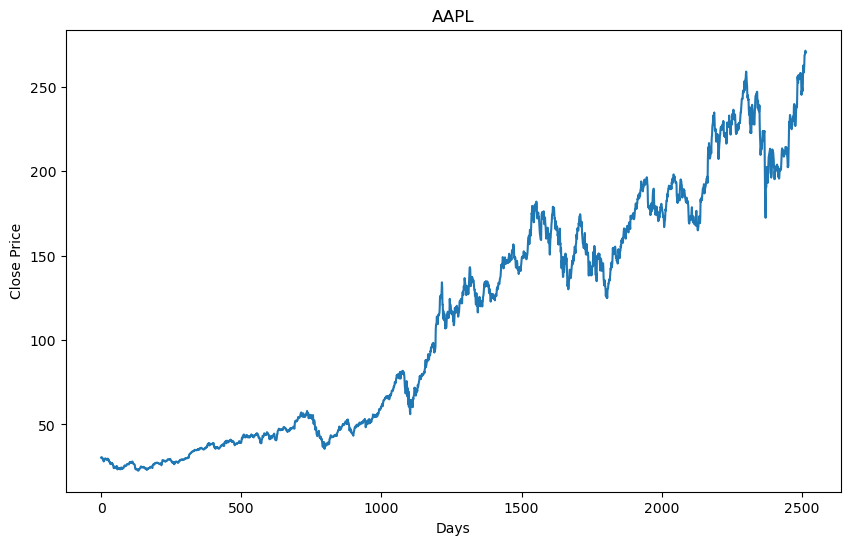

In [46]:
plt.figure(figsize=(10,6))
plt.plot(df['Close'])
plt.title(ticker)
plt.xlabel('Days')
plt.ylabel('Close Price');

# 3. Feature Engineering

In [47]:
# Calculate moving average
# for 5th data...
# temp_df = [10,20,30,40,50,60,70,80,90,100]
# print(sum(temp_df[:5])/5)

In [48]:
df_1 = pd.DataFrame([10,20,30,40,50,60,70,80,90,100])
df_1

,0
0,10
1,20
2,30
3,40
4,50
5,60
6,70
7,80
8,90
9,100


In [49]:
df_1['MA_5'] = df_1.rolling(5).mean()
df_1

,0,MA_5
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


### 100 days moving average

In [50]:
df['MA_100'] = df['Close'].rolling(100).mean()

In [51]:
df.iloc[90:110]

Price,Date,Adj Close,Close,High,Low,Open,Volume,MA_100
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,
90,2016-03-14,23.263033,25.629999,25.727501,25.445000,25.477501,100304400,NaN
91,2016-03-15,23.730471,26.145000,26.295000,25.962500,25.990000,160270800,NaN
92,2016-03-16,24.045881,26.492500,26.577499,26.147499,26.152500,153214000,NaN
93,2016-03-17,24.007309,26.450001,26.617500,26.240000,26.379999,137682800,NaN
94,2016-03-18,24.034531,26.480000,26.625000,26.297501,26.584999,176820800,NaN
95,2016-03-21,24.032263,26.477501,26.912500,26.285000,26.482500,142010800,NaN
96,2016-03-22,24.216063,26.680000,26.822500,26.302500,26.312500,129777600,NaN
97,2016-03-23,24.082182,26.532499,26.767500,26.475000,26.620001,102814000,NaN
98,2016-03-24,23.977808,26.417500,26.562500,26.222500,26.367500,104532000,NaN


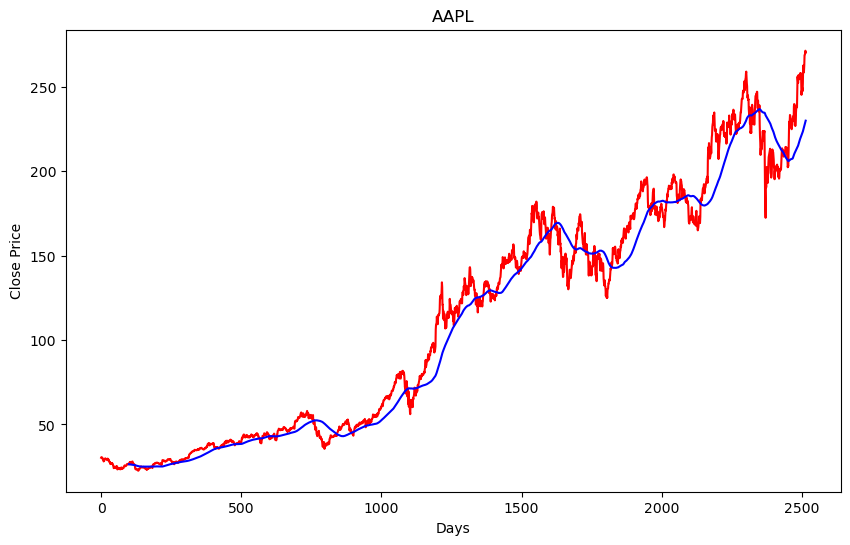

In [52]:
plt.figure(figsize=(10,6))

plt.plot(df['Close'], 'r')
plt.plot(df['MA_100'], 'b')

plt.title(ticker)
plt.xlabel('Days')
plt.ylabel('Close Price');

### 200 days moving average

In [53]:
df['MA_200'] = df['Close'].rolling(200).mean()
df

Price,Date,Adj Close,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2015-11-02,27.232243,30.295000,30.340000,29.902500,30.200001,128813200,NaN,NaN
1,2015-11-03,27.544611,30.642500,30.872499,30.174999,30.197500,182076000,NaN,NaN
2,2015-11-04,27.416521,30.500000,30.955000,30.405001,30.782499,179544400,NaN,NaN
3,2015-11-05,27.290127,30.230000,30.672501,30.045000,30.462500,158210800,NaN,NaN
4,2015-11-06,27.321726,30.264999,30.452499,30.155001,30.277500,132169200,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2510,2025-10-27,268.809998,268.809998,269.119995,264.649994,264.880005,44888200,227.236499,222.61165
2511,2025-10-28,269.000000,269.000000,269.890015,268.149994,268.989990,41534800,227.920199,222.77240
2512,2025-10-29,269.700012,269.700012,271.410004,267.109985,269.279999,51086700,228.578000,222.94890


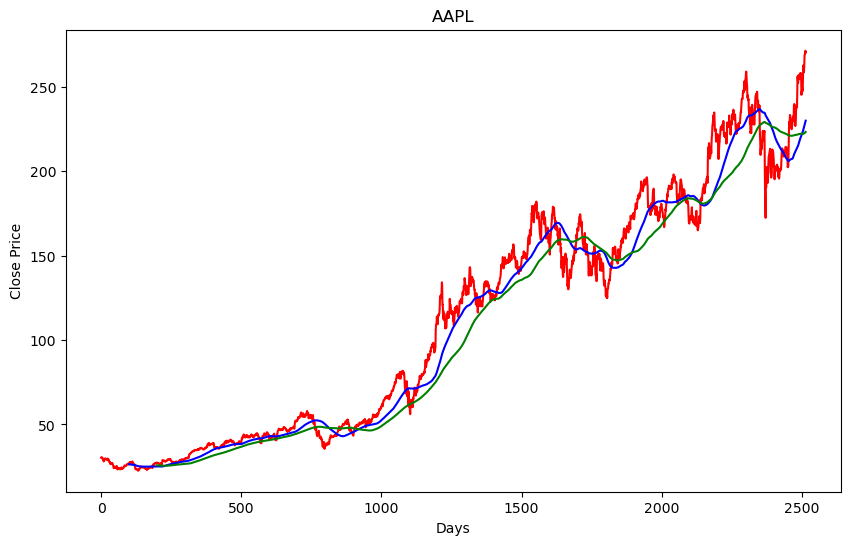

In [54]:
plt.figure(figsize=(10,6))

plt.plot(df['Close'], 'r')
plt.plot(df['MA_100'], 'b')
plt.plot(df['MA_200'], 'g')

plt.title(ticker)
plt.xlabel('Days')
plt.ylabel('Close Price');

### percentage change related to each trading session

In [55]:
df['Percentage Change'] = df['Close'].pct_change()
df[['Close','Percentage Change']]

Price,Close,Percentage Change
Ticker,AAPL,
0,30.295000,NaN
1,30.642500,0.011471
2,30.500000,-0.004650
3,30.230000,-0.008852
4,30.264999,0.001158
...,...,...
2510,268.809998,0.022791
2511,269.000000,0.000707
2512,269.700012,0.002602


In [56]:
df

Price,Date,Adj Close,Close,High,Low,Open,Volume,MA_100,MA_200,Percentage Change
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,,,
0,2015-11-02,27.232243,30.295000,30.340000,29.902500,30.200001,128813200,NaN,NaN,NaN
1,2015-11-03,27.544611,30.642500,30.872499,30.174999,30.197500,182076000,NaN,NaN,0.011471
2,2015-11-04,27.416521,30.500000,30.955000,30.405001,30.782499,179544400,NaN,NaN,-0.004650
3,2015-11-05,27.290127,30.230000,30.672501,30.045000,30.462500,158210800,NaN,NaN,-0.008852
4,2015-11-06,27.321726,30.264999,30.452499,30.155001,30.277500,132169200,NaN,NaN,0.001158
...,...,...,...,...,...,...,...,...,...,...
2510,2025-10-27,268.809998,268.809998,269.119995,264.649994,264.880005,44888200,227.236499,222.61165,0.022791
2511,2025-10-28,269.000000,269.000000,269.890015,268.149994,268.989990,41534800,227.920199,222.77240,0.000707
2512,2025-10-29,269.700012,269.700012,271.410004,267.109985,269.279999,51086700,228.578000,222.94890,0.002602


# 4.Data Preprocessing

In [57]:
df.shape

(2515, 10)

### split data into training & testing

In [58]:
data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.7)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.7):int(len(df))])

print(data_training)
print(data_testing)

Ticker        AAPL
0        30.295000
1        30.642500
2        30.500000
3        30.230000
4        30.264999
...            ...
1755    147.270004
1756    149.449997
1757    152.339996
1758    149.350006
1759    144.800003

[1760 rows x 1 columns]
Ticker        AAPL
1760    155.740005
1761    153.339996
1762    150.649994
1763    145.029999
1764    138.880005
...            ...
2510    268.809998
2511    269.000000
2512    269.700012
2513    271.399994
2514    270.369995

[755 rows x 1 columns]


### scale down whole training data in-between 0 & 1

In [59]:
from sklearn.preprocessing import MinMaxScaler

In [60]:
scaler = MinMaxScaler(feature_range=(0,1))

In [61]:
data_training_array = scaler.fit_transform(data_training) #this returns an array

In [62]:
data_training_array

array([[0.04836131],
       [0.05054101],
       [0.04964718],
       ...,
       [0.81389369],
       [0.79513885],
       [0.76659876]], shape=(1760, 1))

In [63]:
data_training_array.ndim

2

In [64]:
type(data_training_array)

numpy.ndarray

In [65]:
data_training_array.shape

(1760, 1)

# 5.Sequence Creation

In [66]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i,0])

x_train = np.array(x_train)
y_train = np.array(y_train)

In [67]:
x_train, x_train.shape, x_train.ndim

(array([[[0.04836131],
         [0.05054101],
         [0.04964718],
         ...,
         [0.02476086],
         [0.02403952],
         [0.02328682]],
 
        [[0.05054101],
         [0.04964718],
         [0.04795359],
         ...,
         [0.02403952],
         [0.02328682],
         [0.02719148]],
 
        [[0.04964718],
         [0.04795359],
         [0.04817313],
         ...,
         [0.02328682],
         [0.02719148],
         [0.03013957]],
 
        ...,
 
        [[0.80680578],
         [0.77023685],
         [0.77500394],
         ...,
         [0.75775445],
         [0.78209195],
         [0.79576604]],
 
        [[0.77023685],
         [0.77500394],
         [0.79112442],
         ...,
         [0.78209195],
         [0.79576604],
         [0.81389369]],
 
        [[0.77500394],
         [0.79112442],
         [0.78642002],
         ...,
         [0.79576604],
         [0.81389369],
         [0.79513885]]], shape=(1660, 100, 1)),
 (1660, 100, 1),
 3)

In [68]:
y_train, y_train.shape, y_train.ndim

(array([0.02719148, 0.03013957, 0.02924573, ..., 0.81389369, 0.79513885,
        0.76659876], shape=(1660,)),
 (1660,),
 1)

# 6.Model Building

In [69]:
!pip install tensorflow

  Using cached tensorflow-2.20.0-cp313-cp313-win_amd64.whl.metadata (4.6 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.9.23-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached wrapt-2.0.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached grpcio-1.76.0-cp313-cp313-win_amd64.whl.metadata (3.8 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached markdown-3.9-py3-none-any.whl.metadata (5.1 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
  Using cached werkzeug-3.1.3-py3-none-any.whl.metadata (3.7 kB)
Using cached tensorflow-2.20.0-cp313-cp313-win_amd64.whl (332.0 MB)
Using cach

In [70]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [71]:
# ML Model 
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input

In [72]:
# Initialize Sequential Model
model = Sequential()

model.add(Input(shape=(100,1)))
model.add(LSTM(units=128,activation='tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))

# 7.Model Training

In [73]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - loss: 0.0088
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - loss: 7.1311e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 138ms/step - loss: 6.7130e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step - loss: 6.2481e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 162ms/step - loss: 5.6262e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 165ms/step - loss: 5.1319e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 170ms/step - loss: 4.9951e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 131ms/step - loss: 6.1523e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step - loss: 6.3417e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 172ms/step - loss: 4.9671e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - loss: 4.2150e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 142ms/step - loss: 4.5878e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 163ms/step - loss: 4.1865e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 147ms/step - loss: 5.3375e-04
Epoc

In [74]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [75]:
# save the train model
model.save('stock_prediction_model.keras')

# 8.Prepare Test Data

In [77]:
data_testing

Ticker,AAPL
1760,155.740005
1761,153.339996
1762,150.649994
1763,145.029999
1764,138.880005
...,...
2510,268.809998
2511,269.000000
2512,269.700012
2513,271.399994


In [78]:
data_training

Ticker,AAPL
0,30.295000
1,30.642500
2,30.500000
3,30.230000
4,30.264999
...,...
1755,147.270004
1756,149.449997
1757,152.339996
1758,149.350006


In [79]:
past_100_days = data_training.tail(100)

In [80]:
past_100_days

Ticker,AAPL
1660,148.710007
1661,147.960007
1662,142.639999
1663,137.130005
1664,131.880005
...,...
1755,147.270004
1756,149.449997
1757,152.339996
1758,149.350006


In [88]:
final_df = pd.concat([past_100_days,data_testing], ignore_index=True)
final_df

Ticker,AAPL
0,148.710007
1,147.960007
2,142.639999
3,137.130005
4,131.880005
...,...
850,268.809998
851,269.000000
852,269.700012
853,271.399994


### scale down new testing dataset

In [90]:
input_data = scaler.fit_transform(final_df) #this returns an array
input_data.shape

(855, 1)

In [91]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i][0])

x_test = np.array(x_test)
y_test = np.array(y_test)

In [92]:
x_test

array([[[0.16183912],
        [0.15671547],
        [0.12037166],
        ...,
        [0.18663752],
        [0.1662113 ],
        [0.1351278 ]],

       [[0.15671547],
        [0.12037166],
        [0.08272994],
        ...,
        [0.1662113 ],
        [0.1351278 ],
        [0.2098648 ]],

       [[0.12037166],
        [0.08272994],
        [0.04686438],
        ...,
        [0.1351278 ],
        [0.2098648 ],
        [0.19346905]],

       ...,

       [[0.53900808],
        [0.52213418],
        [0.53046866],
        ...,
        [0.94138553],
        [0.98230635],
        [0.98360436]],

       [[0.52213418],
        [0.53046866],
        [0.503894  ],
        ...,
        [0.98230635],
        [0.98360436],
        [0.98838652]],

       [[0.53046866],
        [0.503894  ],
        [0.50676323],
        ...,
        [0.98360436],
        [0.98838652],
        [1.        ]]], shape=(755, 100, 1))

In [93]:
y_test

array([2.09864800e-01, 1.93469055e-01, 1.75092210e-01, 1.36699020e-01,
       9.46851243e-02, 9.12693571e-02, 9.49583398e-02, 9.89206424e-02,
       6.72906043e-02, 1.49269018e-01, 1.68602273e-01, 1.58901507e-01,
       1.70924970e-01, 1.62385552e-01, 1.75570468e-01, 1.79464388e-01,
       1.57056963e-01, 1.71881381e-01, 1.77961546e-01, 1.57740158e-01,
       1.31165493e-01, 1.10329292e-01, 1.57193623e-01, 1.59106445e-01,
       1.55690677e-01, 1.47629517e-01, 1.22216200e-01, 1.08758069e-01,
       1.20439934e-01, 1.17092549e-01, 1.33010037e-01, 1.39704912e-01,
       1.24265681e-01, 7.84260389e-02, 6.48312477e-02, 5.02117681e-02,
       4.97336149e-02, 7.12529068e-02, 4.92553574e-02, 4.67277230e-02,
       3.42260024e-02, 6.96819437e-03, 3.13567704e-02, 3.35428072e-02,
       3.41597573e-04, 9.15428332e-03, 0.00000000e+00, 3.14250482e-02,
       3.50457532e-02, 3.90080557e-02, 5.78631576e-02, 5.73166223e-02,
       6.65391313e-02, 7.46003963e-02, 6.96134053e-02, 7.00232807e-02,
      

# 9.Making Predictions

In [94]:
y_predicted = model.predict(x_test)
y_predicted

24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 176ms/step


array([[0.15987885],
       [0.17384672],
       [0.18407618],
       [0.18374765],
       [0.16798674],
       [0.14028141],
       [0.11784332],
       [0.10516688],
       [0.10050862],
       [0.09026103],
       [0.10636179],
       [0.13169554],
       [0.14863266],
       [0.16138288],
       [0.16557117],
       [0.17015761],
       [0.17440514],
       [0.16955425],
       [0.16892987],
       [0.17166899],
       [0.16775475],
       [0.15486653],
       [0.137434  ],
       [0.13946639],
       [0.14689274],
       [0.15248705],
       [0.15315075],
       [0.14399765],
       [0.13093114],
       [0.12463064],
       [0.12112795],
       [0.12455235],
       [0.13099363],
       [0.13133259],
       [0.11555614],
       [0.0963738 ],
       [0.07790777],
       [0.06514439],
       [0.0640342 ],
       [0.06049714],
       [0.05654858],
       [0.05005767],
       [0.03707328],
       [0.0324447 ],
       [0.03229453],
       [0.02446551],
       [0.01872953],
       [0.012

### revert scaled data into their original state

In [96]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1,1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

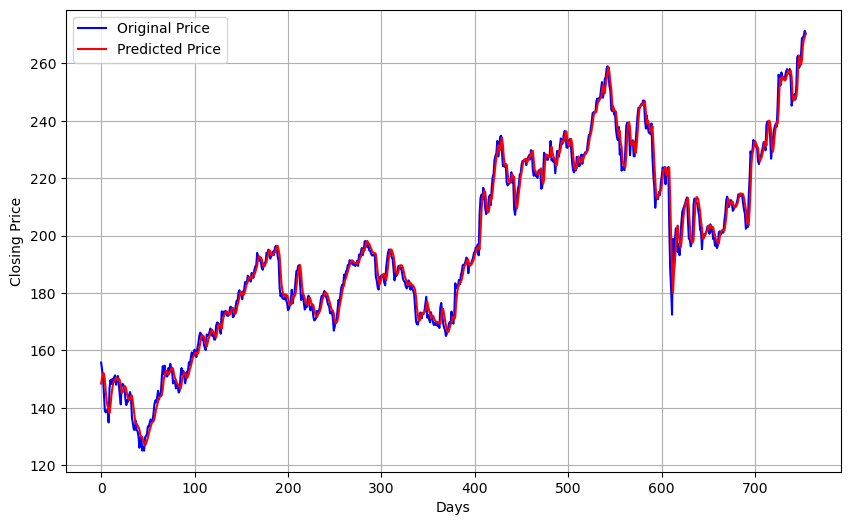

In [100]:
plt.figure(figsize=(10,6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Closing Price')
plt.legend()
plt.grid();

(200.0, 240.0)

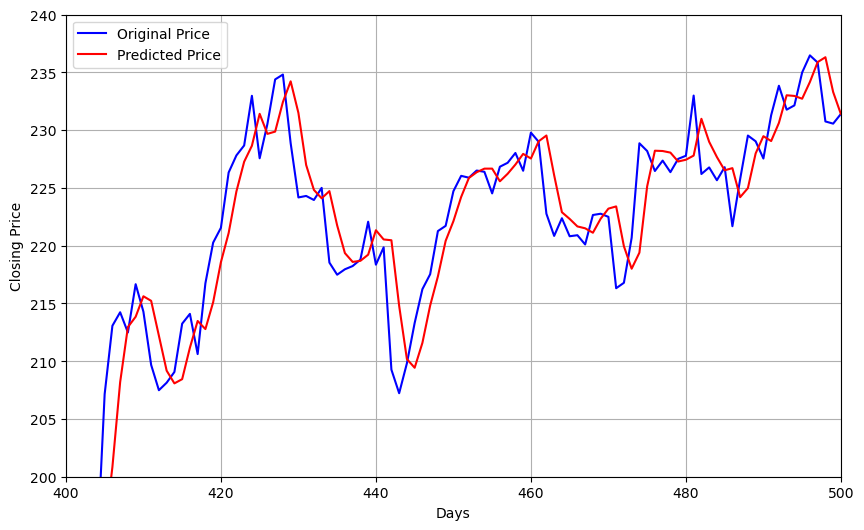

In [99]:
plt.figure(figsize=(10,6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Closing Price')
plt.legend()
plt.grid();

plt.xlim(400,500)
plt.ylim(200,240)

# 10.Model Evaluation

### MSE

In [104]:
from sklearn.metrics import mean_squared_error, r2_score

In [105]:
mse = mean_squared_error(y_test,y_predicted)
mse

15.208764205510501

### Root MSE

In [106]:
rmse = np.sqrt(mse)
rmse

np.float64(3.89984156159074)

### R-Squared

In [107]:
r2 = r2_score(y_test, y_predicted)
r2

0.9854116542228979